# GSR Preprocessing Pipeline
Preprocesses raw Shimmer GSR recordings for all participants (P01–P20).

**Output per participant:** `PXX_gsr_preprocessed.csv` containing:
- `gsr_filt_uS` — 1 Hz low-pass filtered signal
- `gsr_tonic_uS` — tonic component (cvxEDA)
- `gsr_phasic` — phasic driver (cvxEDA)
- `gsr_baseline_corrected_uS` — per-task median baseline corrected signal
- `artifact_flag` — 1 = flagged sample
- `task_id` — 0 = not in task, 1–9 = task number
- `exploration_id` — 0 = not in exploration, 1..N = unique exploration index

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install cvxeda -q

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly, medfilt
import cvxeda
import sys, io
import warnings
warnings.filterwarnings("ignore")

##Parameters

In [ ]:
BASE_DIR = "/content/drive/MyDrive/CAMES/data_collection_training"

PARTICIPANTS = ['P20']  #[f"P{i:02d}" for i in range(1, 21)]  # P01 to P20

#Column names in raw GSR file
TIME_COL  = "t_rel_s"       # relative time in seconds
UNIX_COL  = "timestamp_s"   # absolute unix timestamp
COND_COL  = "gsr_cond_uS"   # conductance in µS

#Column names in tasks / explorations files
TASK_BEGIN_COL    = "begin_s"
TASK_END_COL      = "end_s"
EXPLORATION_BEGIN = "begin_s"
EXPLORATION_END   = "end_s"

#Signal processing (same between participants)
TARGET_FS              = 4     # Hz, EDA standard downsample rate
FILTER_CUTOFF          = 1.0   # Hz, low-pass cutoff before cvxEDA
BASELINE_WINDOW_S      = 60    # s, baseline window before each task onset
ARTIFACT_JUMP_FRACTION = 0.20  # fraction of participant signal range for jump threshold

print("Parameters set.")

Parameters set.


##Helper Functions

In [ ]:
def parse_events(events_file):
    """Parse events file into tasks and explorations DataFrames.

    Args:
        events_file: Path to the TSV log file.

    Returns:
        tuple: (tasks_df, explorations_df)
    """
    df = pd.read_csv(
        events_file,
        sep="\t",
        header=None,
        names=["type", "empty", "hms_begin", "begin_s", "hms_end", "end_s",
               "hms_dur", "duration_s", "label"],
        dtype=str,
    )
    df = df.apply(lambda col: col.str.strip() if col.dtype == object else col)
    df["begin_s"]    = pd.to_numeric(df["begin_s"])
    df["end_s"]      = pd.to_numeric(df["end_s"])
    df["duration_s"] = pd.to_numeric(df["duration_s"])

    tasks = (
        df[df["type"] == "task"][["begin_s", "end_s", "label"]]
        .reset_index(drop=True)
    )
    explorations = (
        df[df["type"] == "exploration"][["begin_s", "end_s"]]
        .reset_index(drop=True)
    )
    return tasks, explorations


def lowpass_filter(signal, cutoff, fs, order=4):                       # fourth-order Butterworth low-pass filter to remove high-frequency noise
    nyq  = fs / 2.0
    b, a = butter(order, cutoff / nyq, btype="low")
    return filtfilt(b, a, signal)


def adaptive_artifact_flag(y_raw, jump_fraction=ARTIFACT_JUMP_FRACTION):          #flagging of 2 types of artifacts: any sample where conductance is negative & any sample where the signal jumps by more than 20% of the participant's own signal range
    signal_range = np.percentile(y_raw, 95) - np.percentile(y_raw, 5)
    threshold    = jump_fraction * signal_range
    dy           = np.abs(np.diff(y_raw, prepend=y_raw[0]))
    return ((y_raw < 0) | (dy > threshold)).astype(int)


def run_cvxeda(y_ds, fs):
    """
    cvxEDA tonic/phasic decomposition.
    Normalises input, decomposes, rescales outputs back to µS.
    Returns (phasic, tonic). If signal is flat, returns (zeros, original).
    """
    mu, sigma = y_ds.mean(), y_ds.std()
    if sigma < 1e-6:
        return np.zeros(len(y_ds)), y_ds.copy()
    yn = (y_ds - mu) / sigma
    r, p, tonic_n, *_ = cvxeda.cvxEDA(yn, 1.0 / fs)
    return np.array(r) * sigma, np.array(tonic_n) * sigma + mu


def baseline_correct(y_filt, time_s, tasks):              #baseline normalisation, 60 seconds immediately before task onset,computingS median conductance in that window, and subtracts it from every sample within the task. Median is used rather than mean
    out = np.full(len(y_filt), np.nan)
    for _, task in tasks.iterrows():
        bl_mask   = (time_s >= task["begin_s"] - BASELINE_WINDOW_S) & \
                    (time_s <  task["begin_s"])
        task_mask = (time_s >= task["begin_s"]) & (time_s <= task["end_s"])
        if bl_mask.sum() > 0:
            out[task_mask] = y_filt[task_mask] - np.median(y_filt[bl_mask])
    return out

def assign_task_ids(time_s, tasks):
    """Empty string = outside any task; otherwise the task label from the events file."""
    ids = np.full(len(time_s), "", dtype=object)
    for _, task in tasks.iterrows():
        ids[(time_s >= task["begin_s"]) & (time_s <= task["end_s"])] = task["label"]
    return ids


def assign_exploration_ids(time_s, explorations):
    """0 = outside any exploration; 1..N = globally unique exploration index."""
    ids = np.zeros(len(time_s), dtype=int)
    for i, (_, exp) in enumerate(explorations.iterrows()):
        ids[(time_s >= exp["begin_s"]) & (time_s <= exp["end_s"])] = i + 1
    return ids


print("Helper functions defined.")

Helper functions defined.


##Main Preprocessing Function

In [ ]:
def preprocess_participant(gsr_file, events_file, participant, output_dir):
    """
    Full preprocessing pipeline for one participant.
    Saves PXX_gsr_preprocessed.csv to output_dir.
    Returns the preprocessed DataFrame.
    """
    print(f"\n{'='*60}")
    print(f"  Participant : {participant}")
    print(f"{'='*60}")

    # 1. Load
    df                   = pd.read_csv(gsr_file, sep=";")
    tasks, explorations  = parse_events(events_file)

    # Remove duplicate timestamps if present (like in P11)
    n_before = len(df)
    df       = df.drop_duplicates(subset=[TIME_COL]).reset_index(drop=True)
    n_after  = len(df)
    if n_before != n_after:
        print(f"  Removed {n_before - n_after} duplicate timestamp rows")

    time_s  = df[TIME_COL].values
    y_raw   = df[COND_COL].values
    fs_orig = 1.0 / np.median(np.diff(time_s))

    print(f"  Duration    : {time_s.max()/60:.1f} min")
    print(f"  Sample rate : {fs_orig:.1f} Hz  →  {TARGET_FS} Hz")
    print(f"  Tasks       : {len(tasks)}")
    print(f"  Explorations: {len(explorations)}")

    # 2. Interpolate over NaN values if present
    n_nans = pd.Series(y_raw).isna().sum()
    if n_nans > 0:
        print(f"  Interpolating {n_nans} NaN values in raw signal")
        y_raw = pd.Series(y_raw).interpolate(
            method="linear", limit_direction="both"
        ).values

    # 3. Median spike removal
    y_med = medfilt(y_raw, kernel_size=3)

    # 4. Low-pass filter
    y_filt = lowpass_filter(y_med, FILTER_CUTOFF, fs_orig)

    # 5. Artifact flags
    art_flag = adaptive_artifact_flag(y_med)
    print(f"  Artifacts   : {art_flag.mean()*100:.1f}% of samples flagged")

    # 6. Per-task baseline correction
    y_bc = baseline_correct(y_filt, time_s, tasks)

    # 7. Task & exploration labels
    task_id  = assign_task_ids(time_s, tasks)
    explo_id = assign_exploration_ids(time_s, explorations)

    # 8. Build dataframe, keep task samples only
    full_df = pd.DataFrame({
        "unix_timestamp"            : df[UNIX_COL].values,
        "timestamp_s"               : time_s,
        "gsr_filt_uS"               : y_filt,
        "gsr_baseline_corrected_uS" : y_bc,
        "artifact_flag"             : art_flag,
        "task_id"                   : task_id,
        "exploration_id"            : explo_id,
    })
    task_df = full_df[full_df["task_id"] != ""].reset_index(drop=True)
    print(f"  Task samples: {len(task_df)} ({len(task_df)/fs_orig/60:.1f} min)")

    # 9. Downsample
    step  = max(1, int(round(fs_orig / TARGET_FS)))
    ds_df = task_df.iloc[::step].reset_index(drop=True)
    print(f"  Downsampled : {len(ds_df)} samples (step={step})")

    # 10. cvxEDA decomposition
    print("  Running cvxEDA (may take 1–2 min)...")
    y_cvx    = ds_df["gsr_filt_uS"].values.copy()
    art_mask = ds_df["artifact_flag"].values.astype(bool)
    if art_mask.any() and (~art_mask).sum() > 10:
        idx   = np.arange(len(y_cvx))
        y_cvx = np.interp(idx, idx[~art_mask], y_cvx[~art_mask])

    phasic, tonic = run_cvxeda(y_cvx, TARGET_FS)
    ds_df["gsr_tonic_uS"] = tonic
    ds_df["gsr_phasic"]   = phasic
    print(f"  Tonic  : {tonic.min():.2f} – {tonic.max():.2f} µS")
    print(f"  Phasic : {phasic.min():.4f} – {phasic.max():.4f} µS")

    # 11. Final column order & save
    ds_df = ds_df[[
        "unix_timestamp", "timestamp_s",
        "gsr_filt_uS", "gsr_tonic_uS", "gsr_phasic",
        "gsr_baseline_corrected_uS",
        "artifact_flag", "task_id", "exploration_id",
    ]]
    os.makedirs(output_dir, exist_ok=True)
    save_path = os.path.join(output_dir, f"{participant}_gsr_preprocessed.csv")
    ds_df.to_csv(save_path, index=False)
    print(f"  Saved → {save_path}")

    # 12. QC table
    print(f"\n  {'Task':<20}  {'Samples':>7}  {'ExpSamples':>10}  "
          f"{'Art%':>5}  {'MeanFilt':>8}  {'MeanTonic':>9}  {'Baseline':>8}")
    for _, task_row in tasks.sort_values("begin_s").iterrows():
        tid    = task_row["label"]
        seg    = ds_df[ds_df["task_id"] == tid]
        n_exp  = (seg["exploration_id"] > 0).sum()
        art_p  = seg["artifact_flag"].mean() * 100
        mf     = seg["gsr_filt_uS"].mean()
        mt     = seg["gsr_tonic_uS"].mean()
        has_bl = "OK" if seg["gsr_baseline_corrected_uS"].notna().any() else "MISSING"
        print(f"  {tid:<20}  {len(seg):>7}  {n_exp:>10}  "
              f"{art_p:>4.1f}%  {mf:>8.2f}  {mt:>9.2f}  {has_bl:>8}")

    return ds_df


print("Main function defined.")

Main function defined.


##Run Batch

> Tilføj citatblok


Processes all participants listed in `PARTICIPANTS`.  
To rerun a single participant, set `PARTICIPANTS = ["P03"]` in the Parameters cell and re-run from there.

In [ ]:
failed  = []
skipped = []

for participant in PARTICIPANTS:
    session_dir = os.path.join(BASE_DIR, participant, f"{participant}_session1")
    gsr_file    = os.path.join(session_dir, f"gsr_{participant}", "gsr_record.csv")
    events_file = os.path.join(session_dir, "event_markers", f"{participant}.txt")

    missing = [f for f in [gsr_file, events_file] if not os.path.exists(f)]
    if missing:
        print(f"[SKIP] {participant} — missing: {[os.path.relpath(f, BASE_DIR) for f in missing]}")
        skipped.append(participant)
        continue

    output_dir = os.path.join(session_dir, f"gsr_{participant}")

    try:
        preprocess_participant(
            gsr_file    = gsr_file,
            events_file = events_file,
            participant = participant,
            output_dir  = output_dir,
        )
    except Exception as e:
        print(f"\n[ERROR] {participant} — {e}")
        failed.append((participant, str(e)))

print(f"\n{'='*60}")
print(f"  Batch complete")
print(f"  Processed : {len(PARTICIPANTS) - len(failed) - len(skipped)} / {len(PARTICIPANTS)}")
if skipped:
    print(f"  Skipped   : {skipped}")
if failed:
    print(f"  Failed    :")
    for p, err in failed:
        print(f"    {p}: {err}")
print(f"{'='*60}")


  Participant : P20
  Removed 8322 duplicate timestamp rows
  Duration    : 98.8 min
  Sample rate : 47.5 Hz  →  4 Hz
  Tasks       : 10
  Explorations: 16
  Artifacts   : 0.0% of samples flagged
  Task samples: 194804 (68.3 min)
  Downsampled : 16234 samples (step=12)
  Running cvxEDA (may take 1–2 min)...
     pcost       dcost       gap    pres   dres
 0: -7.6742e+03 -7.3428e+03  5e+04  2e+02  3e-01
 1: -7.8705e+03 -1.5924e+04  1e+04  4e+01  6e-02
 2: -8.0231e+03 -1.0565e+04  3e+03  9e+00  1e-02
 3: -8.0719e+03 -8.7677e+03  7e+02  2e+00  3e-03
 4: -8.0777e+03 -8.3348e+03  3e+02  6e-01  9e-04
 5: -8.0779e+03 -8.1453e+03  7e+01  8e-02  1e-04
 6: -8.0933e+03 -8.1172e+03  2e+01  3e-02  4e-05
 7: -8.0947e+03 -8.1144e+03  2e+01  2e-02  3e-05
 8: -8.1026e+03 -8.1089e+03  6e+00  5e-03  7e-06
 9: -8.1048e+03 -8.1073e+03  2e+00  1e-03  2e-06
10: -8.1056e+03 -8.1066e+03  1e+00  3e-04  4e-07
11: -8.1060e+03 -8.1063e+03  3e-01  6e-05  9e-08
12: -8.1061e+03 -8.1062e+03  8e-02  1e-05  2e-08
13: -

##VISUALISATIONS
Run this after preprocessing to visually inspect one participant's output.

Loading: /content/drive/MyDrive/CAMES/data_collection_training/P14/P14_session1/gsr_P14/P14_gsr_preprocessed.csv
Exists: True
Samples in task task1_5_2: 1765
Saved QC plot to:
/content/drive/MyDrive/CAMES/data_collection_training/P14/P14_session1/gsr_P14/P14_tasktask1_5_2_qc.pdf


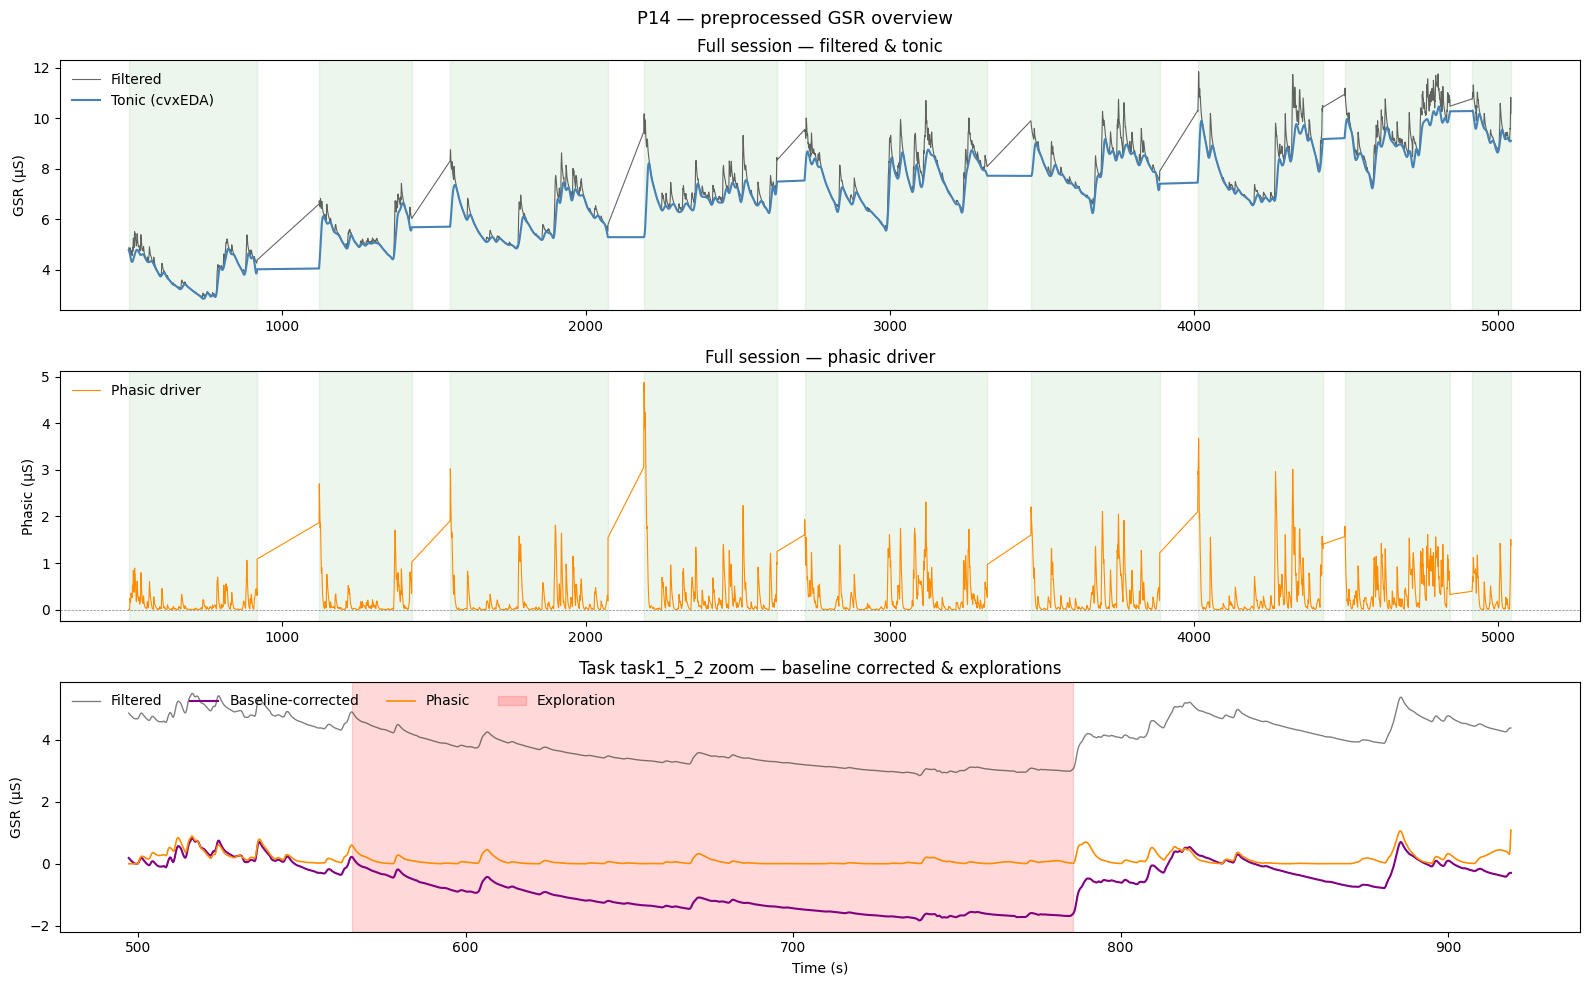

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# SETTINGS
# =========================================================
CHECK_PARTICIPANT = "P14"      # participant to inspect
CHECK_TASK = "task1_5_2"           # task to zoom into

# =========================================================
# LOAD PREPROCESSED FILE
# =========================================================
p_dir = os.path.join(
    BASE_DIR,
    CHECK_PARTICIPANT,
    f"{CHECK_PARTICIPANT}_session1",
    f"gsr_{CHECK_PARTICIPANT}"
)

save_path = os.path.join(
    p_dir,
    f"{CHECK_PARTICIPANT}_gsr_preprocessed.csv"
)

print("Loading:", save_path)
print("Exists:", os.path.exists(save_path))

df_check = pd.read_csv(save_path)

# Optional: ensure task_id is string for matching
df_check["task_id"] = df_check["task_id"].astype(str)

# =========================================================
# CREATE FIGURE
# =========================================================
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=False)
fig.suptitle(
    f"{CHECK_PARTICIPANT} — preprocessed GSR overview",
    fontsize=13
)

# =========================================================
# PANEL 1 — FILTERED + TONIC
# =========================================================
ax = axes[0]

ax.plot(
    df_check["timestamp_s"],
    df_check["gsr_filt_uS"],
    color="black",
    lw=0.8,
    alpha=0.6,
    label="Filtered"
)

ax.plot(
    df_check["timestamp_s"],
    df_check["gsr_tonic_uS"],
    color="steelblue",
    lw=1.5,
    label="Tonic (cvxEDA)"
)

for tid in df_check["task_id"].unique():

    if tid == "0":
        continue

    seg = df_check[df_check["task_id"] == tid]

    ax.axvspan(
        seg["timestamp_s"].iloc[0],
        seg["timestamp_s"].iloc[-1],
        alpha=0.07,
        color="green"
    )

ax.set_ylabel("GSR (µS)")
ax.set_title("Full session — filtered & tonic")
ax.legend(loc="upper left", frameon=False)

# =========================================================
# PANEL 2 — PHASIC DRIVER
# =========================================================
ax = axes[1]

ax.plot(
    df_check["timestamp_s"],
    df_check["gsr_phasic"],
    color="darkorange",
    lw=0.8,
    label="Phasic driver"
)

ax.axhline(0, color="gray", lw=0.5, ls="--")

for tid in df_check["task_id"].unique():

    if tid == "0":
        continue

    seg = df_check[df_check["task_id"] == tid]

    ax.axvspan(
        seg["timestamp_s"].iloc[0],
        seg["timestamp_s"].iloc[-1],
        alpha=0.07,
        color="green"
    )

ax.set_ylabel("Phasic (µS)")
ax.set_title("Full session — phasic driver")
ax.legend(loc="upper left", frameon=False)

# =========================================================
# PANEL 3 — TASK ZOOM
# =========================================================
ax = axes[2]

t_seg = df_check[df_check["task_id"] == CHECK_TASK]

print(f"Samples in task {CHECK_TASK}: {len(t_seg)}")

ax.plot(
    t_seg["timestamp_s"],
    t_seg["gsr_filt_uS"],
    color="black",
    lw=1,
    alpha=0.5,
    label="Filtered"
)

ax.plot(
    t_seg["timestamp_s"],
    t_seg["gsr_baseline_corrected_uS"],
    color="purple",
    lw=1.5,
    label="Baseline-corrected"
)

ax.plot(
    t_seg["timestamp_s"],
    t_seg["gsr_phasic"],
    color="darkorange",
    lw=1.2,
    label="Phasic"
)

# ---------------------------------------------------------
# SHADE EXPLORATION SEGMENTS
# ---------------------------------------------------------
explo_ids = (
    t_seg[t_seg["exploration_id"] > 0]["exploration_id"]
    .unique()
)

for j, eid in enumerate(explo_ids):

    e_seg = t_seg[t_seg["exploration_id"] == eid]

    ax.axvspan(
        e_seg["timestamp_s"].iloc[0],
        e_seg["timestamp_s"].iloc[-1],
        alpha=0.15,
        color="red",
        label="Exploration" if j == 0 else None
    )

# ---------------------------------------------------------
# MARK ARTIFACTS
# ---------------------------------------------------------
art_seg = t_seg[t_seg["artifact_flag"] == 1]

if len(art_seg):

    ax.scatter(
        art_seg["timestamp_s"],
        art_seg["gsr_filt_uS"],
        color="red",
        s=10,
        zorder=5,
        label="Artifact"
    )

ax.set_xlabel("Time (s)")
ax.set_ylabel("GSR (µS)")
ax.set_title(
    f"Task {CHECK_TASK} zoom — baseline corrected & explorations"
)

ax.legend(
    loc="upper left",
    frameon=False,
    ncol=4
)

# =========================================================
# SAVE + SHOW
# =========================================================
plt.tight_layout()

out_path = os.path.join(
    p_dir,
    f"{CHECK_PARTICIPANT}_task{CHECK_TASK}_qc.pdf"
)

plt.savefig(out_path, bbox_inches="tight")

print("Saved QC plot to:")
print(out_path)

plt.show()

Saved → /content/drive/MyDrive/CAMES/data_collection_training/P16/P16_session1/gsr_P16/P16_all_tasks_phasic.pdf


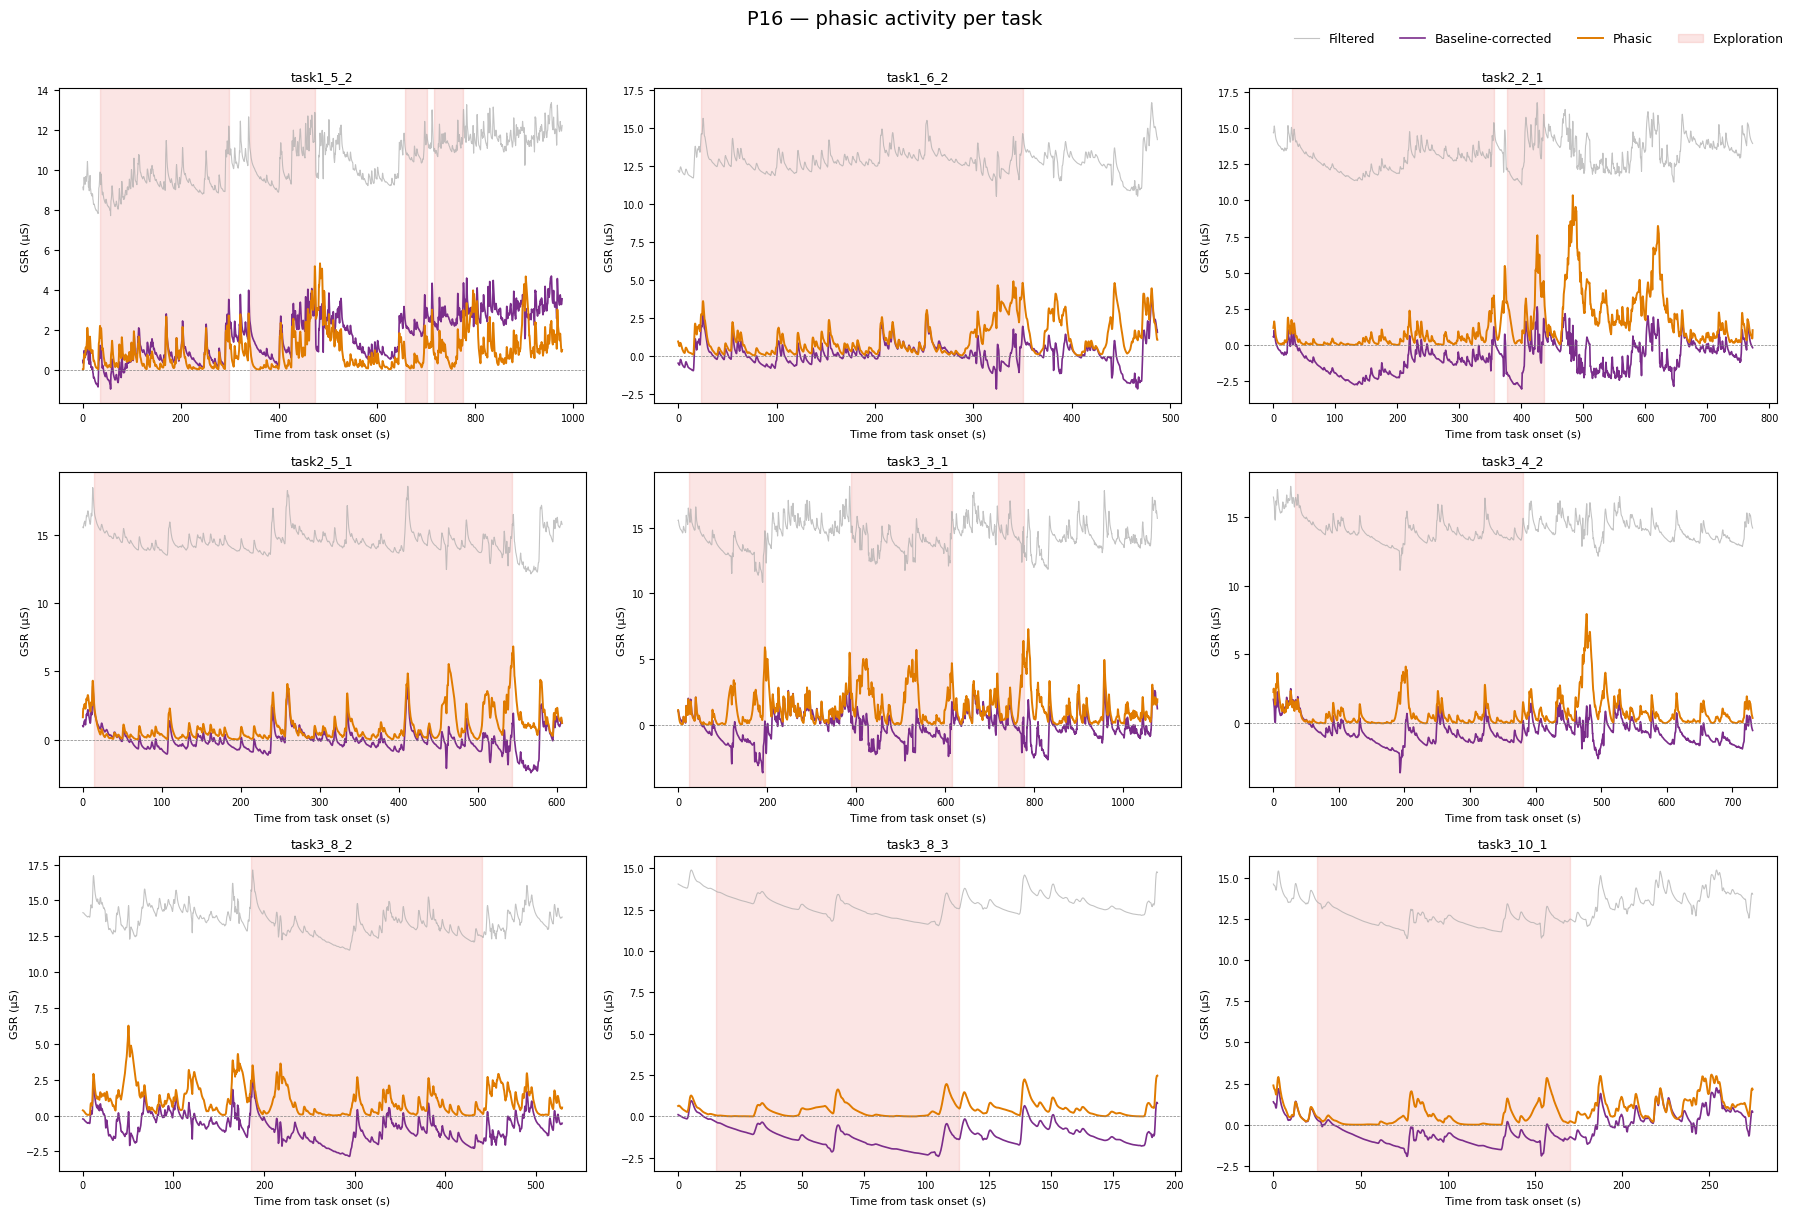

In [ ]:
import os
# =========================================================
# SETTINGS
# =========================================================
CHECK_PARTICIPANT = "P16"   # ← change to explore different participants

# =========================================================
# LOAD
# =========================================================
p_dir = os.path.join(
    BASE_DIR,
    CHECK_PARTICIPANT,
    f"{CHECK_PARTICIPANT}_session1",
    f"gsr_{CHECK_PARTICIPANT}"
)
df = pd.read_csv(os.path.join(p_dir, f"{CHECK_PARTICIPANT}_gsr_preprocessed.csv"))
df["task_id"] = df["task_id"].astype(str)

tasks = [t for t in df["task_id"].unique() if t != ""]

# Sort tasks chronologically by their first timestamp
tasks = sorted(tasks, key=lambda t: df[df["task_id"] == t]["timestamp_s"].iloc[0])

n = len(tasks)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
fig.suptitle(f"{CHECK_PARTICIPANT} — phasic activity per task", fontsize=14, y=1.01)
axes_flat = axes.flatten() if n > 1 else [axes]

for i, task_id in enumerate(tasks):
    ax = axes_flat[i]
    t_seg = df[df["task_id"] == task_id].copy()

    # Convert to time relative to task onset
    t0 = t_seg["timestamp_s"].iloc[0]
    t_rel = t_seg["timestamp_s"] - t0

    # Signals
    ax.plot(t_rel, t_seg["gsr_filt_uS"],
            color="#AAAAAA", lw=0.8, alpha=0.7, label="Filtered")
    ax.plot(t_rel, t_seg["gsr_baseline_corrected_uS"],
            color="#7B2D8B", lw=1.2, label="Baseline-corrected")
    ax.plot(t_rel, t_seg["gsr_phasic"],
            color="#E07B00", lw=1.4, label="Phasic")

    # Exploration shading
    explo_ids = t_seg[t_seg["exploration_id"] > 0]["exploration_id"].unique()
    for j, eid in enumerate(explo_ids):
        e_seg = t_seg[t_seg["exploration_id"] == eid]
        e_rel_start = e_seg["timestamp_s"].iloc[0]  - t0
        e_rel_end   = e_seg["timestamp_s"].iloc[-1] - t0
        ax.axvspan(e_rel_start, e_rel_end,
                   alpha=0.15, color="#E8534A",
                   label="Exploration" if j == 0 else None)

    # Annotation: scr_amp_sum_z if features file is available
    try:
        feat = features_df[
            (features_df["participant"] == CHECK_PARTICIPANT) &
            (features_df["task_id"] == task_id)
        ]
        if len(feat) > 0:
            z = feat["scr_amp_sum_z"].values[0]
            ax.set_title(f"{task_id}\nscr_amp_sum_z = {z:.2f}", fontsize=9)
        else:
            ax.set_title(task_id, fontsize=9)
    except Exception:
        ax.set_title(task_id, fontsize=9)

    ax.axhline(0, color="gray", lw=0.5, ls="--")
    ax.set_xlabel("Time from task onset (s)", fontsize=8)
    ax.set_ylabel("GSR (µS)", fontsize=8)
    ax.tick_params(labelsize=7)

# Shared legend
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", frameon=False,
           ncol=4, fontsize=9, bbox_to_anchor=(1.0, 1.0))

# Hide unused subplots
for j in range(n, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()

out_path = os.path.join(p_dir, f"{CHECK_PARTICIPANT}_all_tasks_phasic.pdf")
plt.savefig(out_path, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

Saved → /content/drive/MyDrive/CAMES/data_collection_training/P16/P16_session1/gsr_P16/P16_publication_figure.pdf


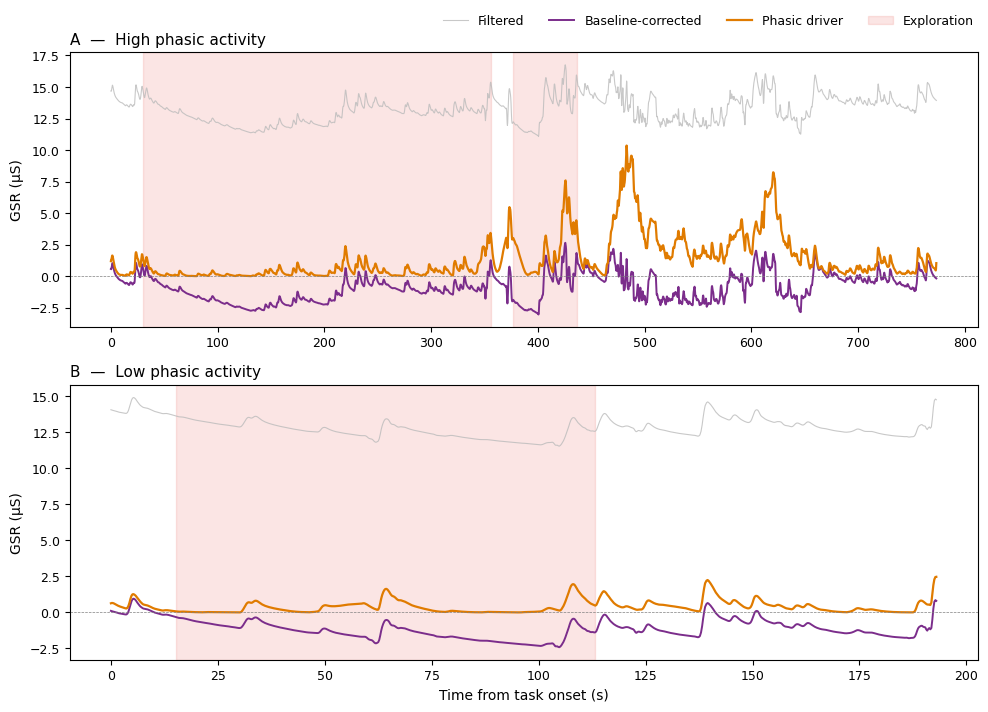

In [ ]:
# =========================================================
# TWO-PANEL PUBLICATION FIGURE
# =========================================================
TASK_HIGH = "task2_2_1"
TASK_LOW  = "task3_8_3"

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=False)

for ax, task_id, label in [
    (axes[0], TASK_HIGH, "A  —  High phasic activity"),
    (axes[1], TASK_LOW,  "B  —  Low phasic activity"),
]:
    t_seg = df[df["task_id"] == task_id].copy()
    t0    = t_seg["timestamp_s"].iloc[0]
    t_rel = t_seg["timestamp_s"] - t0

    ax.plot(t_rel, t_seg["gsr_filt_uS"],
            color="#BBBBBB", lw=0.8, alpha=0.8, label="Filtered")
    ax.plot(t_rel, t_seg["gsr_baseline_corrected_uS"],
            color="#7B2D8B", lw=1.4, label="Baseline-corrected")
    ax.plot(t_rel, t_seg["gsr_phasic"],
            color="#E07B00", lw=1.6, label="Phasic driver")

    for j, eid in enumerate(t_seg[t_seg["exploration_id"] > 0]["exploration_id"].unique()):
        e_seg = t_seg[t_seg["exploration_id"] == eid]
        ax.axvspan(e_seg["timestamp_s"].iloc[0] - t0,
                   e_seg["timestamp_s"].iloc[-1] - t0,
                   alpha=0.15, color="#E8534A",
                   label="Exploration" if j == 0 else None)

    ax.axhline(0, color="gray", lw=0.5, ls="--")
    ax.set_ylabel("GSR (µS)", fontsize=10)
    ax.set_title(label, fontsize=11, loc="left")
    ax.tick_params(labelsize=9)

axes[1].set_xlabel("Time from task onset (s)", fontsize=10)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", frameon=False,
           ncol=4, fontsize=9, bbox_to_anchor=(0.99, 1.02))

plt.tight_layout()
pub_path = os.path.join(p_dir, f"{CHECK_PARTICIPANT}_publication_figure.pdf")
plt.savefig(pub_path, bbox_inches="tight", dpi=300)
print(f"Saved → {pub_path}")
plt.show()

## Participant QC Summary

| P | Tonic range (µS) | Usable tasks | Issues | Excluded tasks | Notes |
|---|---|---|---|---|---|
| P01 | 9–16 | 9/10 | Recording gap | task3_3_1 (no GSR data) | Phasic artefact near gap. task3_4_2second unique to P01. |
| P02 | 3–16 | 6/7 | Recording gap | task3_8_2 (post-gap) | task3_4_2 and task3_4_2second not performed. |
| P03 | 4–9 | 10/10 | — | — | Low responder. task3_3_1 very low exploration coverage (13%). |
| P04 | 1–14 | 9/9 | — | — | Split recording merged. Long session (143 min). |
| P05 | −24–22 | 5/9 | Recording gap + NaN values | task3_4_2 (negative tonic), task3_8_2, task3_8_3, task3_10_1 (post-gap) | 44 NaN values near gap. Early tasks fully reliable. |
| P06 | 0–6 | 9/9 | — | — | Low responder. Minor cvxEDA staircase artefact. task3_3_1 low exploration (13%). |
| P07 | 4–12 | 9/9 | — | — | Short session (58 min). One exploration per task. Very short explorations in later tasks. |
| P08 | −2–7 | 9/9 | Minor | — | Low responder. Minor negative tonic dips (cvxEDA staircase). All task means positive. |
| P09 | 0–2 | 9/9 | Very low SNR | — | Extremely low responder (1–2 µS). Phasic features may reflect noise. Sensitivity analysis recommended. |
| P10 | 5–10 | 7/7 | — | — | Skipped task2_5_1 and task3_3_1. Only 7 tasks performed. |
| P11 | 1–5 | 4/9 | Recording ended early | task3_3_1 onwards (recording ended 2.6s before task start) | 149,974 duplicate timestamps removed. Recording ended at 46.9 min. |
| P12 | 1–4 | 3/9 | Recording ended early | task2_5_1 onwards (recording ended mid-task2_2_1) | 220,184 duplicate timestamps removed. task2_2_1 80% captured. Extremely low responder. |
| P13 | 2–11 | 9/9 | — | — | task3_3_1 very low exploration coverage (9%). One exploration per task. |
| P14 | 3–10 | 9/9 | — | — | Clean complete recording. |
| P15 | 3–8 | 9/9 | — | — | 14 explorations — multiple exploration periods per task. |
| P16 | 5–15 | 9/9 | — | — | High responder. 15 explorations. |
| P17 | 5–13 | 9/9 | — | — | Very short explorations in task3_8_3 and task3_10_1 (~62s each). |
| P18 | −1–5 | 9/9 | Minor | — | Low responder. Minor negative tonic dips in task3_8_2 and task3_8_3 (cvxEDA staircase). |
| P19 | 4–12 | 9/9 | — | — | Clean complete recording. |
| P20 | 16–25 | 6/10 | Recording ended early | task3_4_2 onwards (recording ended before task start) | Highest responder. task3_3_1 exploration fully captured despite partial task window. |